1. Data Loading & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# 1. Đọc file dữ liệu
folder_path = r"D:\PTDLKinhDoanh\Dataset\all_fuels_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

  ticker  commodity       date       open       high        low      close  \
0   CL=F  Crude Oil  8/23/2000  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  8/24/2000  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  8/25/2000  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  8/28/2000  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  8/29/2000  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  


In [3]:
# 2. Kiểm tra dữ liệu ban đầu
print("=== 5 dòng đầu tiên của dữ liệu ===")
print(df.head())

print("\n=== Các loại hàng hóa có trong dữ liệu ===")
print(df['commodity'].unique())

print("\n=== Thông tin tổng quan về dữ liệu ===")
print(df.info())

=== 5 dòng đầu tiên của dữ liệu ===
  ticker  commodity       date       open       high        low      close  \
0   CL=F  Crude Oil  8/23/2000  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  8/24/2000  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  8/25/2000  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  8/28/2000  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  8/29/2000  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  

=== Các loại hàng hóa có trong dữ liệu ===
['Crude Oil' 'Heating Oil' 'Natural Gas' 'RBOB Gasoline' 'Brent Crude Oil']

=== Thông tin tổng quan về dữ liệu ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28075 entries, 0 to 28074
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ticker     28075 non-null  object 
 1   commodity  28075 non-null  obj

In [4]:
# 3. Xử lý cột ngày tháng
df['date'] = pd.to_datetime(df['date'])

In [5]:
# 4. Kiểm tra dữ liệu sau khi xử lý ngày tháng
print("\n=== Kiểm tra kiểu dữ liệu sau khi chuyển đổi ===")
print(df.dtypes)


=== Kiểm tra kiểu dữ liệu sau khi chuyển đổi ===
ticker               object
commodity            object
date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume                int64
dtype: object


In [6]:
# 5. Kiểm tra missing values
print("\n=== Kiểm tra giá trị thiếu ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Kiểm tra giá trị thiếu ===
ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [7]:
# Kiểm tra xem dữ liệu có ngày bị thiếu không
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = date_range.difference(df['date'])

print("Các ngày thiếu trong dữ liệu:", missing_dates)

Các ngày thiếu trong dữ liệu: DatetimeIndex(['2000-08-26', '2000-08-27', '2000-09-02', '2000-09-03',
               '2000-09-04', '2000-09-09', '2000-09-10', '2000-09-16',
               '2000-09-17', '2000-09-23',
               ...
               '2024-05-27', '2024-06-01', '2024-06-02', '2024-06-08',
               '2024-06-09', '2024-06-15', '2024-06-16', '2024-06-19',
               '2024-06-22', '2024-06-23'],
              dtype='datetime64[ns]', length=2717, freq=None)


In [8]:
# Chỉ xử lý missing values nếu có
if df.isnull().sum().any():
    # Forward-fill (ưu tiên cho chuỗi thời gian)
    df.fillna(method='ffill', inplace=True)
    
    # Interpolation cho các trường hợp cần làm mượt (tùy chọn)
    # df['close'] = df['close'].interpolate(method='linear')
    print("Đã xử lý missing values")
else:
    print("Không phát hiện missing values - Bỏ qua bước này")

Không phát hiện missing values - Bỏ qua bước này


In [9]:
# Kiểm tra giá trị rỗng
empty_strings = (df == "").sum()
print("Số lượng chuỗi rỗng trên mỗi cột:\n", empty_strings)

Số lượng chuỗi rỗng trên mỗi cột:
 ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [10]:
# Kiểm tra số lượng hàng trùng lặp
print("Số lượng hàng trùng lặp:", df.duplicated().sum())

Số lượng hàng trùng lặp: 0


In [11]:
# 6. Kiểm tra outliers và thống kê cơ bản
print("\n=== Thống kê mô tả dữ liệu ===")
print(df.describe())


=== Thống kê mô tả dữ liệu ===
                                date          open          high  \
count                          28075  28075.000000  28075.000000   
mean   2013-02-15 07:20:35.476402432     27.288994     27.680580   
min              2000-08-23 00:00:00    -14.000000      0.507000   
25%              2007-09-11 00:00:00      2.031000      2.060550   
50%              2013-04-23 00:00:00      3.374000      3.450000   
75%              2018-11-21 00:00:00     54.895000     55.745001   
max              2024-06-24 00:00:00    146.080002    147.429993   
std                              NaN     36.085625     36.540236   

                low         close        volume  
count  28075.000000  28075.000000  2.807500e+04  
mean      26.873389     27.287224  1.059926e+05  
min      -40.320000    -37.630001  0.000000e+00  
25%        1.998200      2.031250  2.641100e+04  
50%        3.301000      3.375900  4.903300e+04  
75%       53.910000     54.900000  1.147245e+05  
max  

In [12]:
# Tìm các dòng có giá trị âm ở các cột numeric liên quan đến giá
cols = ['open', 'high', 'low', 'close']
negative_values = df[df[cols].lt(0).any(axis=1)]

print("\n=== Các dòng có giá trị âm ===")
print(negative_values)



=== Các dòng có giá trị âm ===
     ticker  commodity       date   open   high    low      close   volume
4931   CL=F  Crude Oil 2020-04-20  17.73  17.85 -40.32 -37.630001   247947
4932   CL=F  Crude Oil 2020-04-21 -14.00  13.86 -16.74  10.010000  2288230


In [15]:
zero_volume_df = df[df['volume'] == 0]
print(f"Số dòng có volume = 0: {len(zero_volume_df)}")
print(zero_volume_df)


Số dòng có volume = 0: 107
      ticker        commodity       date        open        high         low  \
36      CL=F        Crude Oil 2000-10-13   35.930000   35.959999   34.900002   
63      CL=F        Crude Oil 2000-11-21   35.400002   35.700001   35.000000   
121     CL=F        Crude Oil 2001-02-16   29.200001   29.250000   29.100000   
137     CL=F        Crude Oil 2001-03-13   27.799999   27.900000   27.450001   
262     CL=F        Crude Oil 2001-09-10   27.750000   28.000000   27.570000   
...      ...              ...        ...         ...         ...         ...   
25274   BZ=F  Brent Crude Oil 2013-04-16  100.360001  100.360001  100.360001   
25297   BZ=F  Brent Crude Oil 2013-05-17  103.720001  103.720001  103.720001   
25367   BZ=F  Brent Crude Oil 2013-08-30  115.110001  115.389999  113.660004   
26031   BZ=F  Brent Crude Oil 2016-05-02   48.099998   48.099998   48.099998   
27769   BZ=F  Brent Crude Oil 2023-04-06   84.830002   85.440002   84.050003   

            

Trực quan hóa để xem Outlier

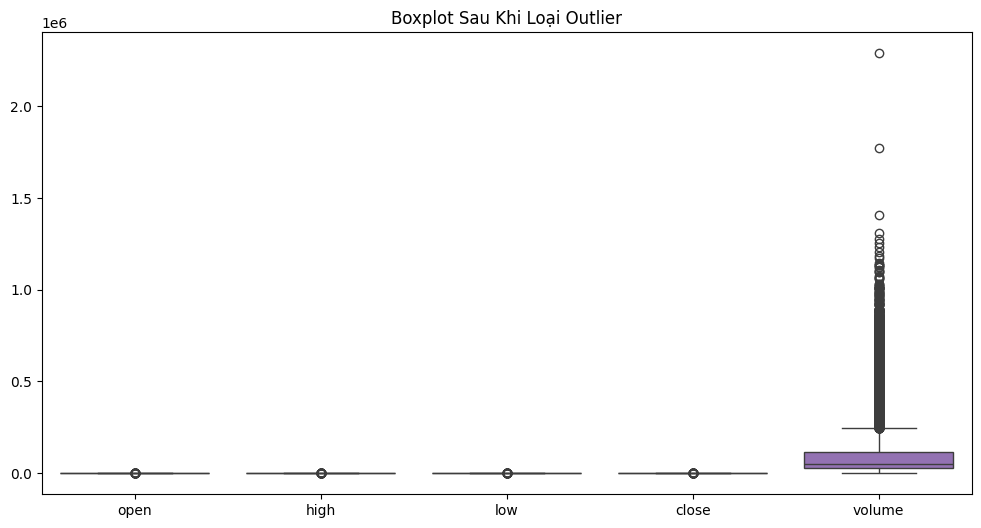

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['open', 'high', 'low', 'close', 'volume']])
plt.title('Boxplot Sau Khi Loại Outlier')
plt.show()


Outlier ở open, high, low, close rất ít => Không cần loại bỏ
Outlier ở volume nhiều nên cần xử lý => loại bỏ outlier sẽ làm giảm dữ liệu nhưng thể hiện được xu hướng chung

In [17]:
Q1 = df['volume'].quantile(0.25)  # Lấy phần tư thứ nhất (25%)
Q3 = df['volume'].quantile(0.75)  # Lấy phần tư thứ ba (75%)
IQR = Q3 - Q1                     # Tính khoảng IQR

# Tính ngưỡng thấp và cao
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [18]:
df_clean = df[(df['volume'] >= lower_bound) & (df['volume'] <= upper_bound)]


In [19]:
print("Số dòng ban đầu:", len(df))
print("Số dòng sau khi loại outlier:", len(df_clean))


Số dòng ban đầu: 28075
Số dòng sau khi loại outlier: 24593


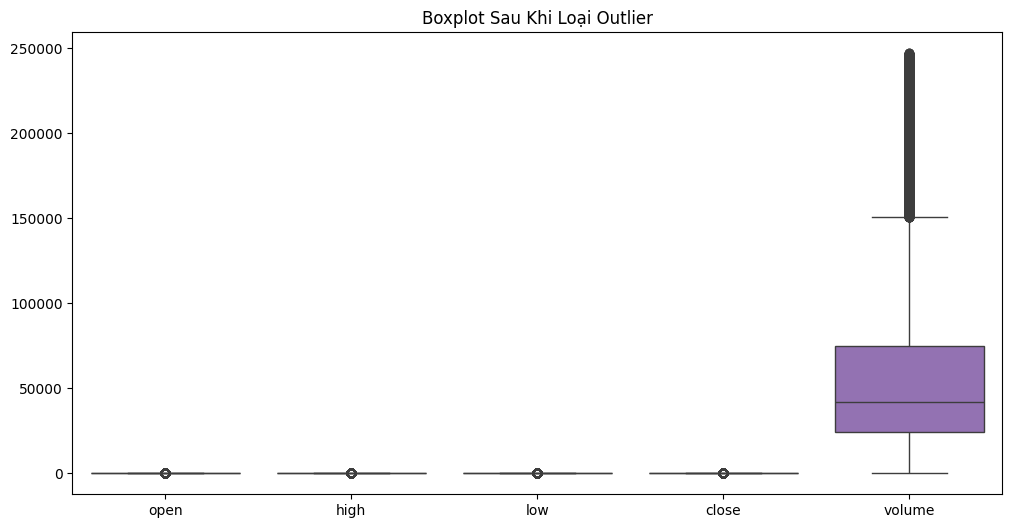

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[['open', 'high', 'low', 'close', 'volume']])
plt.title('Boxplot Sau Khi Loại Outlier')
plt.show()


In [24]:
zero_volume_df = df_clean[df_clean['volume'] == 0]
print(f"Số dòng có volume = 0: {len(zero_volume_df)}")
print(zero_volume_df)


Số dòng có volume = 0: 107
      ticker        commodity       date        open        high         low  \
36      CL=F        Crude Oil 2000-10-13   35.930000   35.959999   34.900002   
63      CL=F        Crude Oil 2000-11-21   35.400002   35.700001   35.000000   
121     CL=F        Crude Oil 2001-02-16   29.200001   29.250000   29.100000   
137     CL=F        Crude Oil 2001-03-13   27.799999   27.900000   27.450001   
262     CL=F        Crude Oil 2001-09-10   27.750000   28.000000   27.570000   
...      ...              ...        ...         ...         ...         ...   
25274   BZ=F  Brent Crude Oil 2013-04-16  100.360001  100.360001  100.360001   
25297   BZ=F  Brent Crude Oil 2013-05-17  103.720001  103.720001  103.720001   
25367   BZ=F  Brent Crude Oil 2013-08-30  115.110001  115.389999  113.660004   
26031   BZ=F  Brent Crude Oil 2016-05-02   48.099998   48.099998   48.099998   
27769   BZ=F  Brent Crude Oil 2023-04-06   84.830002   85.440002   84.050003   

            

In [31]:
# Tìm các dòng có giá trị âm ở các cột numeric liên quan đến giá
cols = ['open', 'high', 'low', 'close']
negative_values = df_clean[df_clean[cols].lt(0).any(axis=1)]

print("\n=== Các dòng có giá trị âm ===")
print(negative_values)



=== Các dòng có giá trị âm ===
Empty DataFrame
Columns: [ticker, commodity, date, open, high, low, close, volume]
Index: []


In [33]:
outliers = df[(df['volume'] < lower_bound) | (df['volume'] > upper_bound)]
print(outliers)

      ticker    commodity       date       open       high        low  \
1570    CL=F    Crude Oil 2006-12-07  62.310001  62.759998  61.549999   
1587    CL=F    Crude Oil 2007-01-03  60.950001  60.970001  57.720001   
1588    CL=F    Crude Oil 2007-01-04  58.349998  58.580002  55.389999   
1589    CL=F    Crude Oil 2007-01-05  55.410000  56.400002  54.900002   
1590    CL=F    Crude Oil 2007-01-08  56.240002  57.720001  55.099998   
...      ...          ...        ...        ...        ...        ...   
17827   NG=F  Natural Gas 2024-01-10   3.167000   3.226000   2.956000   
17829   NG=F  Natural Gas 2024-01-12   3.118000   3.377000   3.102000   
17848   NG=F  Natural Gas 2024-02-09   1.885000   1.885000   1.817000   
17850   NG=F  Natural Gas 2024-02-13   1.754000   1.786000   1.654000   
17931   NG=F  Natural Gas 2024-06-10   2.980000   3.096000   2.862000   

           close  volume  
1570   62.490002  255423  
1587   58.320000  248547  
1588   55.590000  324010  
1589   56.31000

Trực quan hóa số lượng volume trong từng tháng của mỗi năm

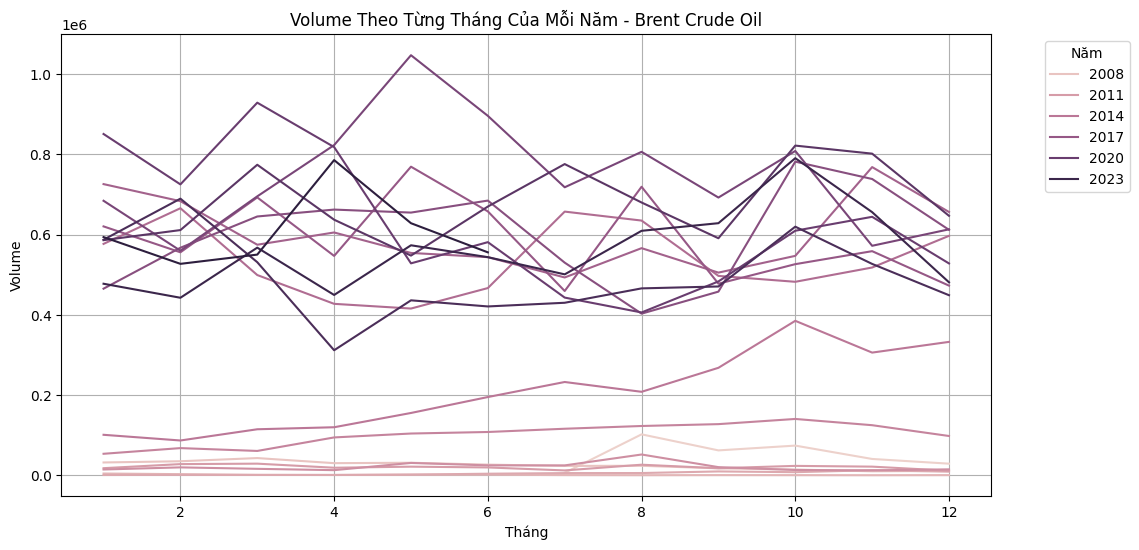

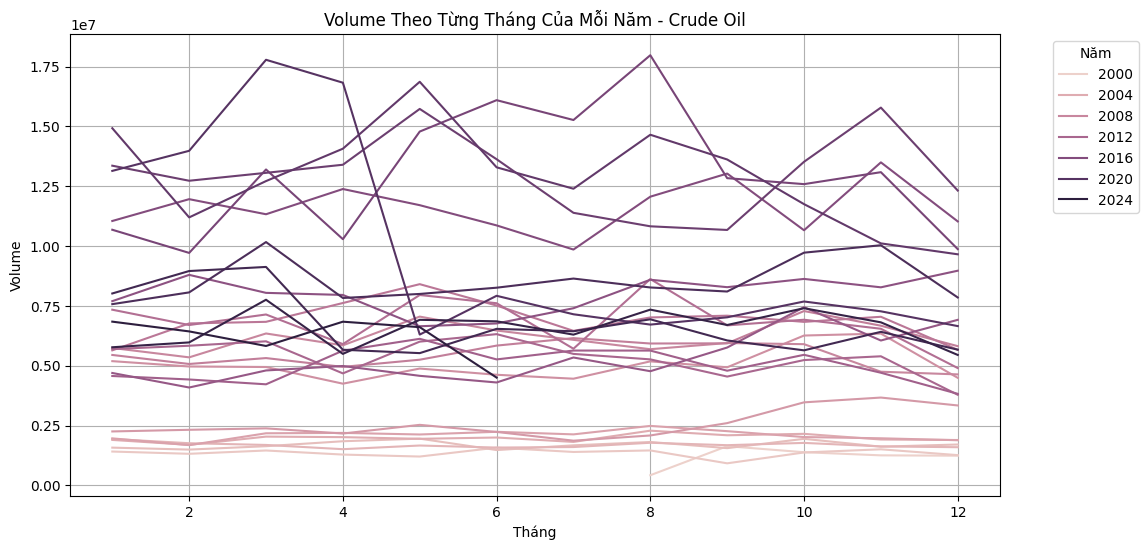

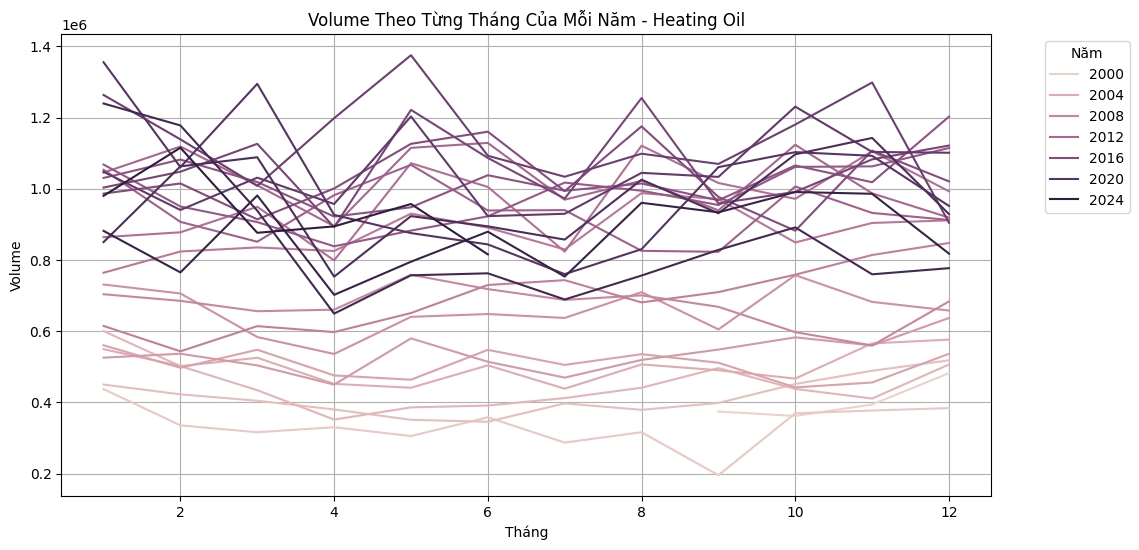

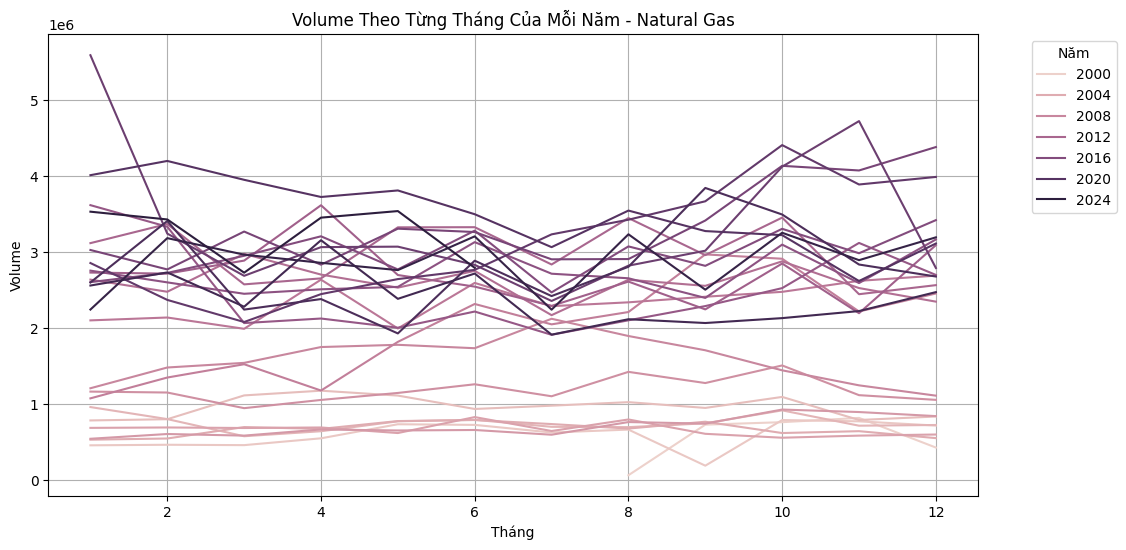

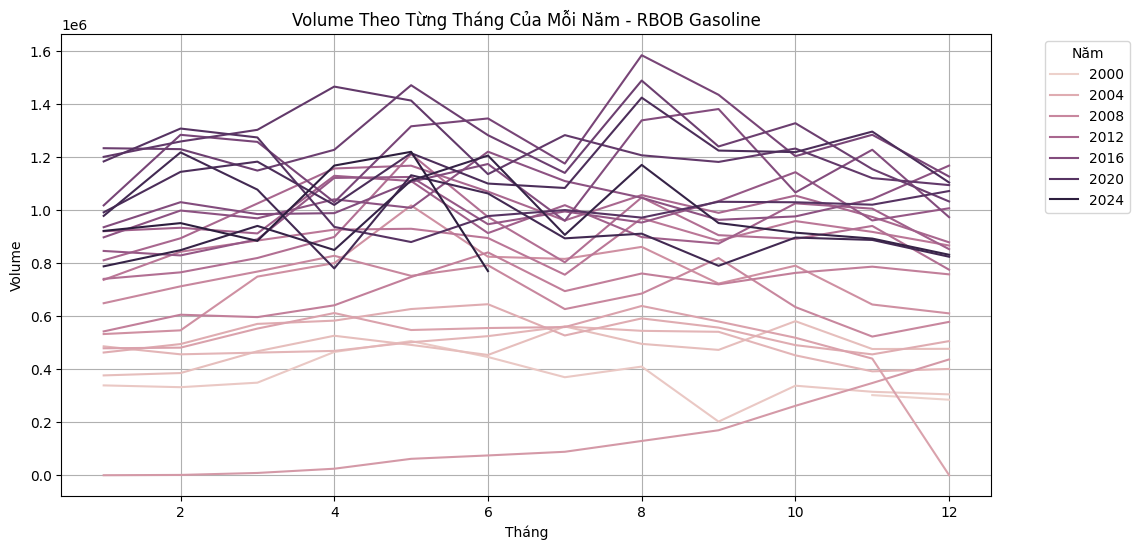

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo cột 'date' là kiểu datetime
df['date'] = pd.to_datetime(df['date'])

# Tạo cột 'year' và 'month'
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Tính tổng volume theo từng tháng của mỗi năm cho từng commodity
monthly_volume = df.groupby(['commodity', 'year', 'month'])['volume'].sum().reset_index()

# Lặp qua từng loại commodity và vẽ biểu đồ riêng
unique_commodities = monthly_volume['commodity'].unique()

for commodity in unique_commodities:
    plt.figure(figsize=(12, 6))
    subset = monthly_volume[monthly_volume['commodity'] == commodity]
    sns.lineplot(data=subset, x='month', y='volume', hue='year', markers=True)
    plt.title(f'Volume Theo Từng Tháng Của Mỗi Năm - {commodity}')
    plt.xlabel('Tháng')
    plt.ylabel('Volume')
    plt.legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()